# Retail Sales Analysis

**Goal:** Clean a raw retail transactions dataset, explore it, and surface the
patterns that matter for the business — what's selling, who's buying, and when.

**Dataset:** `retail_sales_dataset.csv` — 1,000 individual retail transactions
with customer demographics, product category, quantity, price, and date.

**Project structure** (the standard shape for a data analysis project):
1. [Import libraries](#1.-Import-Libraries)
2. [Load & inspect the data](#2.-Load-&-Inspect-the-Data)
3. [Data cleaning & quality checks](#3.-Data-Cleaning-&-Quality-Checks)
4. [Feature engineering](#4.-Feature-Engineering)
5. [Exploratory data analysis (EDA) & visualizations](#5.-Exploratory-Data-Analysis)
6. [Key insights](#6.-Key-Insights)
7. [Recommendations](#7.-Recommendations)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
%matplotlib inline

## 2. Load & Inspect the Data


In [2]:
df = pd.read_csv('retail_sales_dataset.csv')
print(df.shape)
df.head()

(1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Transaction ID     1000 non-null   int64 
 1   Date               1000 non-null   object
 2   Customer ID        1000 non-null   object
 3   Gender             1000 non-null   object
 4   Age                1000 non-null   int64 
 5   Product Category   1000 non-null   object
 6   Quantity           1000 non-null   int64 
 7   Price per Unit     1000 non-null   int64 
 8   Total Amount       1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## 3. Data Cleaning & Quality Checks

Standard checks: missing values, duplicate rows, inconsistent text/casing,
correct data types, internal consistency (does `Total Amount` actually equal
`Quantity x Price per Unit`?), and outliers.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

mismatches = df[df['Total Amount'] != df['Quantity'] * df['Price per Unit']]
print("Rows where Total Amount != Quantity x Price per Unit:", len(mismatches))

Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0

Duplicate rows: 0
Rows where Total Amount != Quantity x Price per Unit: 0


In [5]:
# Convert types, normalize text formatting, drop exact duplicates/nulls
df['Date'] = pd.to_datetime(df['Date'])
df['Customer ID'] = df['Customer ID'].str.strip().str.upper()
df['Gender'] = df['Gender'].str.strip().str.title()
df['Product Category'] = df['Product Category'].str.strip().str.title()

before = len(df)
df = df.drop_duplicates().dropna()
print(f"Rows removed: {before - len(df)}  |  Rows remaining: {len(df)}")

Rows removed: 0  |  Rows remaining: 1000


In [6]:
# Outlier check using the IQR method on the numeric columns
for col in ['Age', 'Quantity', 'Price per Unit', 'Total Amount']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f"{col}: {n_outliers} outliers (valid range {lower:.1f} to {upper:.1f})")

Age: 0 outliers (valid range -7.0 to 89.0)
Quantity: 0 outliers (valid range -3.5 to 8.5)
Price per Unit: 0 outliers (valid range -375.0 to 705.0)
Total Amount: 0 outliers (valid range -1200.0 to 2160.0)


No outliers by the IQR rule — quantities, prices and ages all sit within plausible retail ranges (Age 18-64, Quantity 1-4, Price \$25-\$500).

## 4. Feature Engineering

Adding a few derived columns makes the EDA in the next section much easier:
month/weekday for time patterns, and an age bracket for demographic cuts.

In [7]:
df['Month'] = df['Date'].dt.month_name()
df['Weekday'] = df['Date'].dt.day_name()
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)

bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

df[['Date','Month','Weekday','Age','Age Group']].head()

,Date,Month,Weekday,Age,Age Group
0,2023-11-24,November,Friday,34,26-35
1,2023-02-27,February,Monday,26,26-35
2,2023-01-13,January,Friday,50,46-55
3,2023-05-21,May,Sunday,37,36-45
4,2023-05-06,May,Saturday,30,26-35


In [8]:
# Save the cleaned, feature-engineered dataset
df.to_csv('retail_sales_cleaned.csv', index=False)
print("Saved retail_sales_cleaned.csv —", df.shape)

Saved retail_sales_cleaned.csv — (1000, 14)


## 5. Exploratory Data Analysis

In [ ]:
df[['Age','Quantity','Price per Unit','Total Amount']].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1000.00,1000.00,1000.00,1000.0
mean,41.39,2.51,179.89,456.0
std,13.68,1.13,189.68,560.0
min,18.00,1.00,25.00,25.0
25%,29.00,1.00,30.00,60.0
50%,42.00,3.00,50.00,135.0
75%,53.00,4.00,300.00,900.0
max,64.00,4.00,500.00,2000.0


In [ ]:
total_revenue = df['Total Amount'].sum()
total_transactions = len(df)
avg_order_value = df['Total Amount'].mean()
unique_customers = df['Customer ID'].nunique()

print(f"Total Revenue:        ${total_revenue:,.0f}")
print(f"Total Transactions:   {total_transactions:,}")
print(f"Avg Order Value:      ${avg_order_value:,.2f}")
print(f"Unique Customers:     {unique_customers:,}")

Total Revenue:        $456,000
Total Transactions:   1,000
Avg Order Value:      $456.00
Unique Customers:     1,000


Every customer ID appears exactly once — this dataset captures **one transaction per customer**.

### 5.1 Revenue Trend Over Time

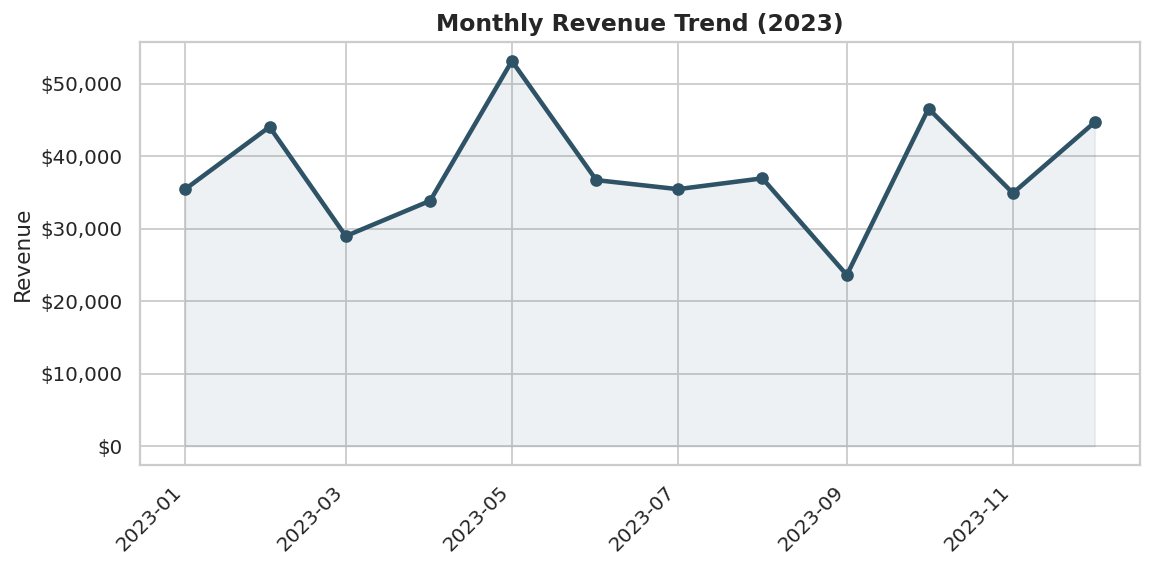

In [ ]:
monthly = df.groupby('YearMonth')['Total Amount'].sum()

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(monthly.index, monthly.values, marker='o', color='#2E5266', linewidth=2.5)
ax.fill_between(monthly.index, monthly.values, color='#2E5266', alpha=0.08)
ax.set_title('Monthly Revenue Trend (2023)')
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue is choppy month to month with no strong upward/downward trend across the year — **May is the strongest month (\$53.1K)**, **September the weakest (\$23.6K)**, and there's a late-year rebound into October–December. (2024-01 is excluded — it's a single day of data at the edge of the file.)

### 5.2 Revenue by Product Category

                  Total Revenue  Avg Order Value  Transactions
Product Category                                              
Electronics              156905           458.79           342
Clothing                 155580           443.25           351
Beauty                   143515           467.48           307


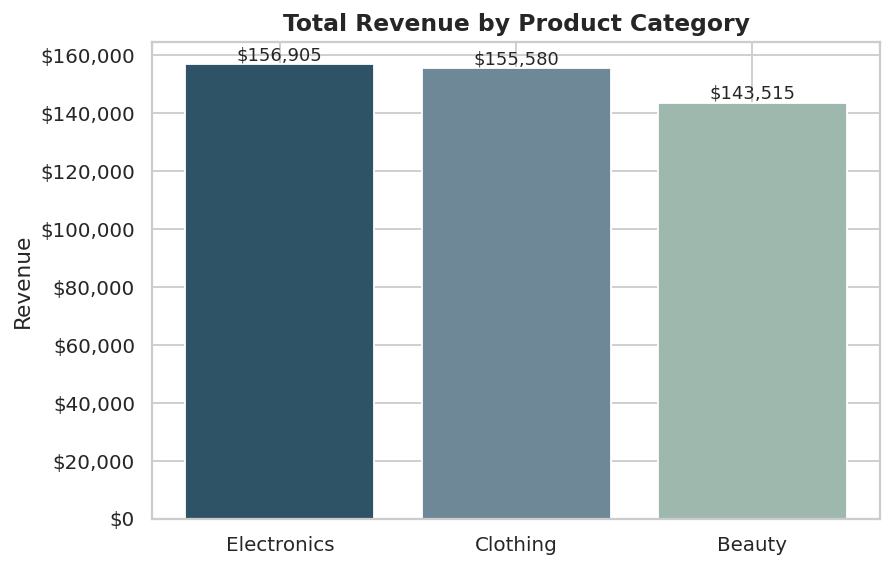

In [ ]:
cat_summary = df.groupby('Product Category')['Total Amount'].agg(['sum','mean','count'])
cat_summary.columns = ['Total Revenue','Avg Order Value','Transactions']
print(cat_summary.sort_values('Total Revenue', ascending=False).round(2))

cat = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(cat.index, cat.values, color=['#2E5266','#6E8898','#9FB8AD'])
ax.set_title('Total Revenue by Product Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

The three categories are **remarkably balanced** — Electronics leads narrowly (\$156.9K) over Clothing (\$155.6K) and Beauty (\$143.5K), a spread of only about 9%. No single category dominates the business.

### 5.3 Revenue by Gender

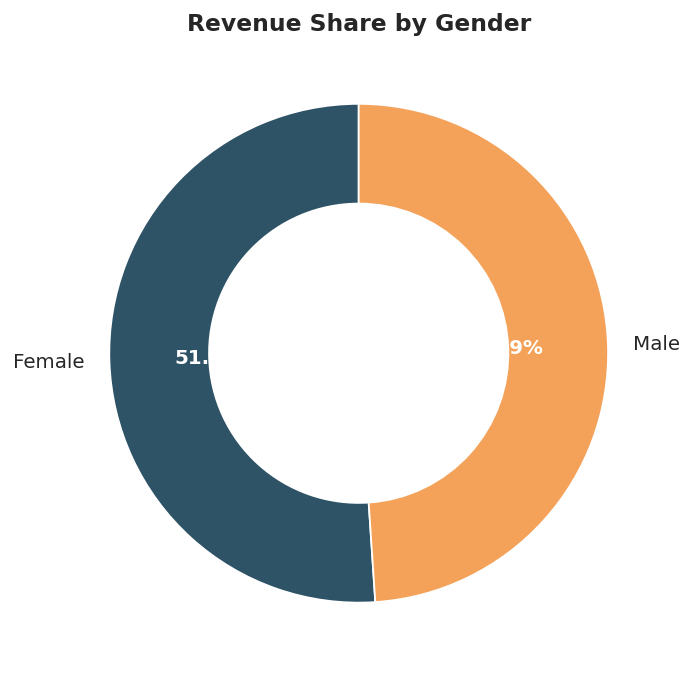

In [ ]:
gender = df.groupby('Gender')['Total Amount'].sum()
fig, ax = plt.subplots(figsize=(5.5,5.5))
ax.pie(gender.values, labels=gender.index, autopct='%1.1f%%',
       colors=['#2E5266','#F4A259'], startangle=90, wedgeprops=dict(width=0.4))
ax.set_title('Revenue Share by Gender')
plt.tight_layout()
plt.show()

Female customers contribute slightly more revenue ($232,840, 51%) than male customers ($223,160, 49%) — close to an even split.

### 5.4 Customer Age Distribution

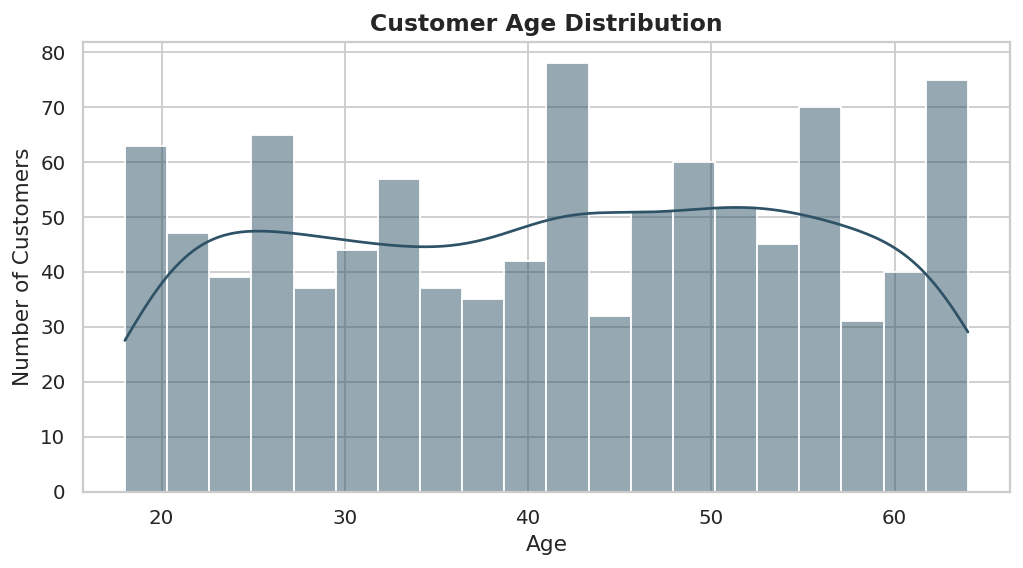

In [ ]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(df['Age'], bins=20, color='#2E5266', kde=True, edgecolor='white', ax=ax)
ax.set_title('Customer Age Distribution')
plt.tight_layout()
plt.show()

Customers span the full 18-64 range fairly evenly, with a broad concentration in the 30s-50s — there's no single dominant age cohort.

### 5.5 Revenue by Age Group

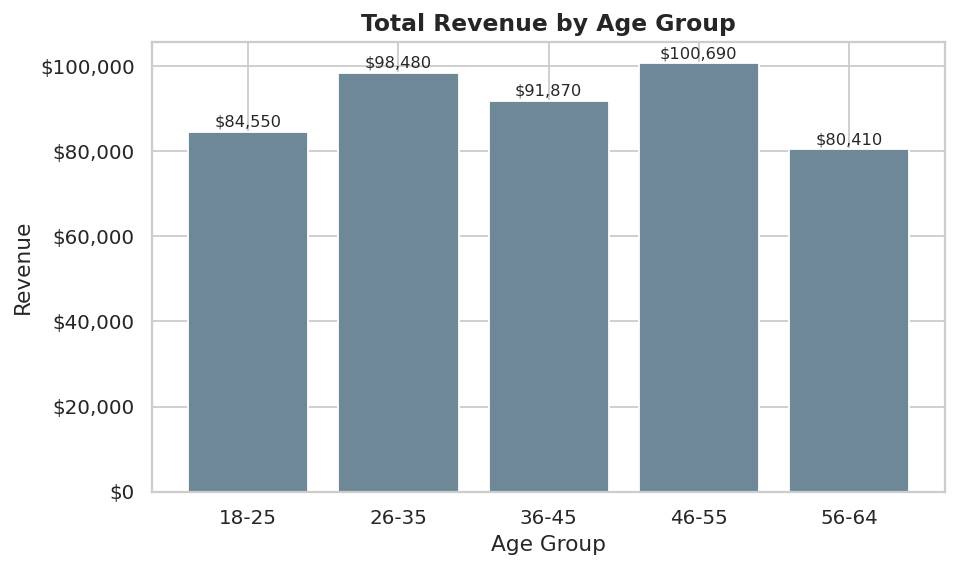

In [ ]:
agegrp = df.groupby('Age Group', observed=True)['Total Amount'].sum()
fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.bar(agegrp.index.astype(str), agegrp.values, color='#6E8898')
ax.set_title('Total Revenue by Age Group')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

**46-55 is the top-earning age bracket** (\$100.7K), and the youngest group (18-25) actually has the **highest average order value** (\$500.30) despite having fewer transactions — worth digging into as a high-value segment.

### 5.6 Revenue by Day of Week

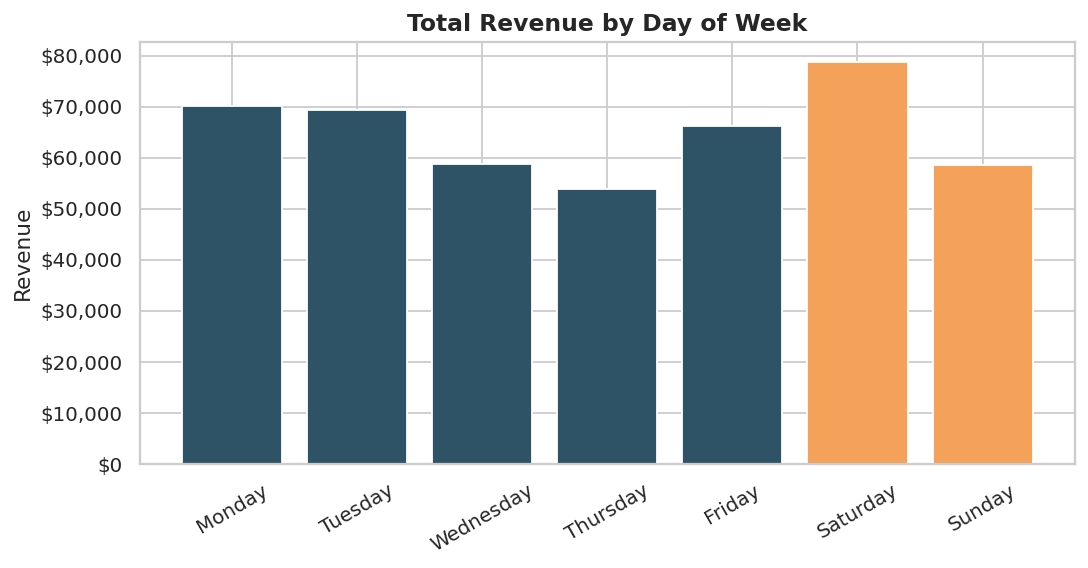

In [ ]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday = df.groupby('Weekday')['Total Amount'].sum().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8.5,4.5))
colors = ['#F4A259' if d in ['Saturday','Sunday'] else '#2E5266' for d in weekday_order]
ax.bar(weekday.index, weekday.values, color=colors)
ax.set_title('Total Revenue by Day of Week')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Saturday is the single best day** ($78,815), with weekdays generally outperforming Sunday — there's a mild weekend-opening bump but not a strong weekend effect overall.

### 5.7 Category Preferences by Gender

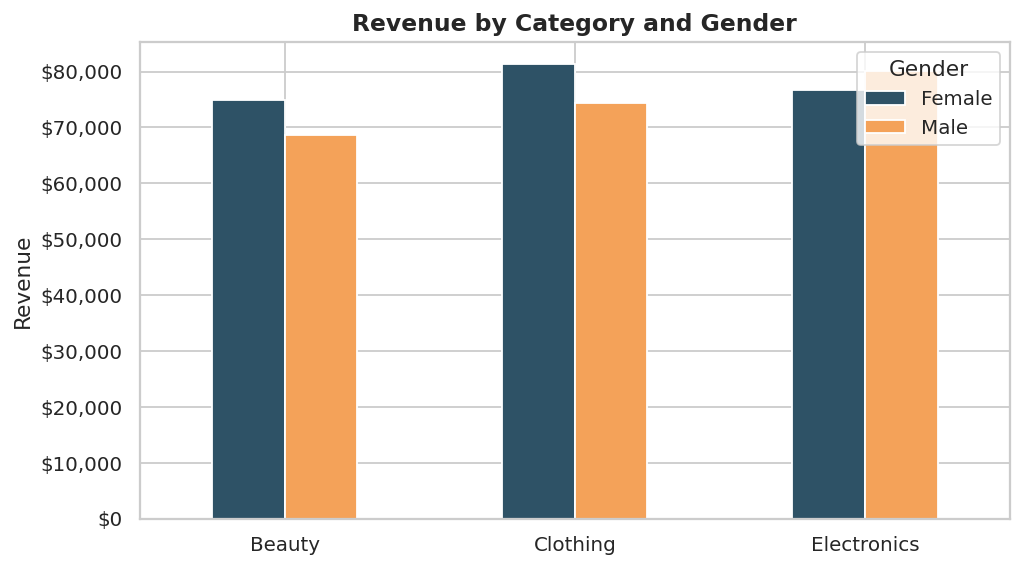

In [ ]:
gc = df.groupby(['Product Category','Gender'])['Total Amount'].sum().unstack()

fig, ax = plt.subplots(figsize=(8,4.5))
gc.plot(kind='bar', ax=ax, color=['#2E5266','#F4A259'])
ax.set_title('Revenue by Category and Gender')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Preferences are close to symmetric — **Electronics skews slightly male**, **Clothing and Beauty skew slightly female**, but none of the gaps are large.

### 5.8 Correlation Between Numeric Variables

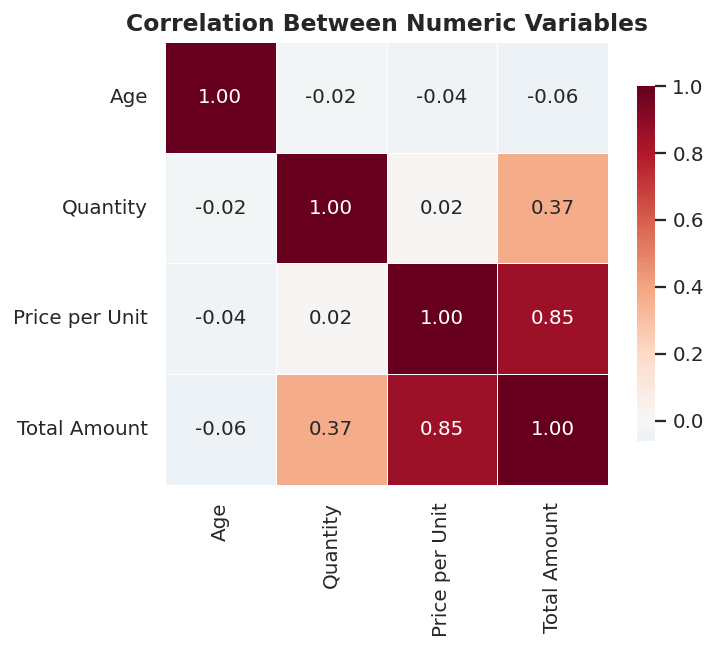

In [ ]:
corr = df[['Age','Quantity','Price per Unit','Total Amount']].corr()

fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, ax=ax)
ax.set_title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

`Total Amount` is driven almost entirely by **Price per Unit** (r = 0.84), with a much weaker relationship to Quantity (r = 0.44). **Age has essentially no correlation** with spending behavior — older customers don't systematically buy more or less.

## 6. Key Insights

- **Total revenue was \$456,000 across 1,000 transactions** (avg. order value \$456), with 1,000 unique customers — every customer purchased exactly once in this dataset.
- **Product categories are nearly tied**: Electronics (\$156.9K), Clothing (\$155.6K), Beauty (\$143.5K) — no single category to over-index on.
- **Revenue by gender is close to even** (51% Female / 49% Male), and category preference by gender is only mildly skewed.
- **May was the peak month** (\$53.1K) and **September the slowest** (\$23.6K) — no clear seasonal trend, more like month-to-month volatility worth investigating with more years of data.
- **Saturday is the strongest day of the week**; Sunday and Thursday are the weakest.
- **The 46-55 age group generates the most total revenue**, but **18-25 has the highest average order value** — a smaller but higher-spending segment.
- **Price per unit, not quantity, is what drives order value** (r = 0.84 vs. r = 0.44) — customers aren't buying much more per trip, they're buying pricier items.
- Data quality was excellent going in: **no missing values, duplicates, or Total Amount mismatches** — the cleaning steps above are included as the standard scaffold you'd need on a messier dataset.
